In [1]:
import matplotlib.pyplot as plt
import pymaster as nmt
import healpy as hp
import numpy as np

# SOOPERCOOL tutorial n°1 - Transfer function definitions

Disclaimer: the purpose of this notebook is not to provide code to estimate transfer function for SO-SAT analyses. Below, you will find a breakdown of the methods used to compute a transfer function from simulations and incorporate it in the final bandpower couplings and bandpower window functions.

### Standard approach

Below we describe the approach that has been explored in https://arxiv.org/abs/2502.00946. The main assumption is that the effect of filtering can be captured by a transfer function in bandpowers $T_{b}^{AB}$ defined as
$$
    \tilde{C}_b^{A, {\rm F}} = \sum_{B} T_{b}^{AB} \tilde{C}_b^{B}
$$
where
- $A$, $B$ are different field pairs (i.e. $EE$, $EB$, ...)
- ${\rm F}$ is a superscript to denote "filtered"
- $\tilde{C}$ are pseudo-$C_\ell$ s (i.e. they are not corrected from mask-induced couplings) 

**How to estimate the transfer function**

We start by generating pure $T$,$E$,$B$ simulations, filter them and compute all possible power spectra. We model the filtered simulations (PLF below) as
$$
    \begin{align}
        \tilde{C}^{{\rm PLF}, AB}_b &= \sum_{D} T_b^{AD} \sum_{i\in b} w_b^i \sum_{j} M_{DiBj} C_{j}^{\rm PL},\\
        &= \sum_{D} T_b^{AD} \mathcal{D}_{DBb}
    \end{align}
$$
where $B$ labels pure pairs, $D$ and $A$ label field pairs. We then fix $A$ (the field pair axis), summarize all pure pairs in vectors and solve a linear system to estimate the transfer function.
$$
    \begin{align}
        \mathbf{t}^A &= \left( T_b^{A, EE} T_b^{A, EB} \cdots T_b^{A, BB} \right) \\
        \hat{\mathbf{C}}^A &= \left( \tilde{C}_b^{{\rm PLF}, A, EE} \cdots \tilde{C}_b^{{\rm PLF}, A, BB} \right)
    \end{align}
$$
The least square solution is
$$
    \hat{\mathbf{t}}^A = (\mathsf{D}^\top \mathsf{D})^{-1} \mathsf{D}^\top \hat{\mathbf{C}}^A
$$

**Estimate coupling matrices and bandpower window functions**
- **Binned couplings**
$$
    \begin{align}
        \mathcal{W}_{AkBp} &= \sum_{C} T_k^{AC} \sum_{i\in k}w_k^i \sum_{j\in p} M_{CiBj} \\
        &= \sum_{C} T_k^{AC} \mathcal{M}_{CkBp}
    \end{align}
$$
where $\mathcal{M}$ is the binned mode coupling matrix
- **Bandpower window functions**
$$
    \mathcal{B}_{AkBi} = \sum_{Cp} (\mathcal{W}^{-1})_{AkCp} \sum_{D} T_p^{CD}\sum_{j\in p} w_p^j M_{DjBi}
$$
where we basically just bin the mode-coupling matrix on the left, multiply by the transfer function and then by the inverse coupling as defined above.

### Alternative approach

In the alternative approach, the transfer function is defined as $T_\ell^{AB}$ and will directly act on the $C_\ell$ (not bandpowers). We then write
$$
    \langle \tilde{C}_b^{A,{\rm F}} \rangle = \sum_{i \in b} w_b^i \sum_{B, j} M_{AiBj}\sum_{D} T_{j}^{BD} C_{j}^{D},
$$
where
- $\sum_{i\in b} w_b^i$: this is the binning operator (what we define below "on the left")
- $M_{AiBj}$ is the mask mode coupling matrix (that we get from `Namaster`)
- $i$, $j$ subscripts correspond to a multipole index

The main problem with this approach is that we won't be able to estimate the transfer functions at every $\ell$, therefore we need to rely on a basis expansion $T_{i} = \sum_k \phi_i^k T_k$, where the functions $\phi$ need to be defined.

**How to estimate the transfer function**

From pure $T$,$E$,$B$ simulations as above, we write the decoupled power spectra $\hat{C}$ as
$$
    \begin{align}
        \hat{C}_b^{{\rm PLF}, AB} &= \sum_{Dp} T_p^{DB} \sum_{Em} (\mathcal{M}^{-1})_{AbEm}\sum_{i\in m} w_m^i \sum_j M_{EiDj}\phi_j^p C_j^{\rm PL} \\
        &= \sum_{Dp} T_p^{DB} \mathcal{D}_{AbDp}
    \end{align}
$$
where $\mathcal{M}$ is the binned mode coupling matrix and there is an arbitrary choice to be made for the basis functions $\phi$. The above expression can be expressed as a matrix multiplication, this time fixing the pure pairs $B$
$$
    \hat{\mathbf{C}}^{B} = \mathsf{D} \mathbf{t}^{B} \implies \mathbf{t}^B = (\mathsf{D}^\top\mathsf{D})^{-1}\mathsf{D}^\top \hat{\mathbf{C}}^B
$$


**Estimate coupling matrices and bandpower window functions**

- **Binned couplings**
$$
\begin{align}
    \mathcal{W}_{Ak,Bp} &= \sum_{C} \sum_{i\in k} \sum_{j\in p} w_k^i M_{AiCj}T_j^{CB} \\
    &= \sum_{i\in k}\sum_{j\in p} w_k^i \left( \sum_C M_{AiCj}T_j^{CB} \right) \\
    &= \sum_{i\in k}\sum_{j\in p} w_k^i (MT)_{AiBj}
\end{align}
$$
where the last line is just the binning operation on a standard mode coupling matrix (both left and right)
- **Bandpower window functions**
$$
\begin{align}
    \mathcal{B}_{AkBi} &= \sum_{Cp}\sum_{j\in p}\sum_{D} (\mathcal{W}^{-1})_{Ak,Cp}w_p^j M_{CjDi}T_i^{DB} \\
    &= \sum_{Cp} (\mathcal{W}^{-1})_{Ak,Cp} \sum_{j\in p} w_p^j (MT)_{CjBi}
\end{align}
$$
where the last sum is the standard left-binning operation.

## Numerical example

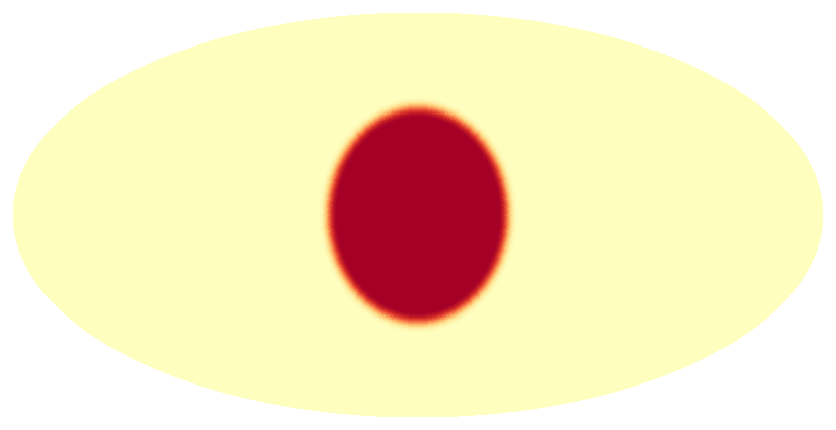

In [2]:
nside = 128

m = np.zeros((12*nside**2))
m[hp.query_disc(nside, hp.ang2vec(np.pi/2, 0.), np.pi/4)] = 1.
m = nmt.mask_apodization(m, aposize=10, apotype="C1")

hp.mollview(m, cmap="RdYlBu_r", title="", cbar=False, min=-1, max=1)

Then we create all relevant objects to compute pseudo-$C_\ell$s and decouple them using `Namaster`.
You can change:
- `bin_size`: number of multipoles in a bin
- `purify_b`: whether or not to apply mask-based purification with `Namaster`

We precompute the mode coupling matrix that will be used in this notebook. For polarization only, its shape should be `(4, n_ell, 4, n_ell)`.

In [3]:
bin_size = 10
purify_b = False

b = nmt.NmtBin.from_nside_linear(nside, bin_size, is_Dell=False)

f = nmt.NmtField(m, None, spin=2, lmax=3*nside-1, purify_b=purify_b)
w = nmt.NmtWorkspace.from_fields(f, f, b)
mcm = np.transpose(
    w.get_coupling_matrix().reshape([3*nside, 4, 3*nside, 4]),
    axes=[1, 0, 3, 2]
)

We define below three utility functions
- `m_filter_map`: a test filtering function for the purpose of this demo
- `bin_mcm_left`: bin a coupling matrix from the left
- `bin_mcm_right`: bin a coupling matrix from the right

In [4]:
def m_filter_map(map, mask, m_cut):
    """
    This is a dummy filter, getting rid of all modes with
    m <= m_cut. It is a useful test case for our transfer
    function formalism.
    """
    binary = mask.copy()
    binary[binary != 0] = 1.
    map_masked = map * binary
    nside = hp.get_nside(map)
    lmax = 3 * nside - 1
    alms = hp.map2alm(map_masked, lmax=lmax)
    n_modes_to_filter = (m_cut + 1) * (lmax + 1) - ((m_cut + 1) * m_cut) // 2
    alms[:, :n_modes_to_filter] = 0.
    filtered_map = hp.alm2map(alms, nside=nside, lmax=lmax)
    return filtered_map

def bin_mcm_left(mcm, nmt_binning):
    """
    This is taken from the SOOPERCOOL codebase.
    It is used to bin any coupling matrix on the left
    i.e. (size, nl, size, nl) -> (size, n_bins, size, nl)
    """
    if mcm.ndim != 4:
        raise ValueError("Input mcm must be a 4D array.")

    nl = nmt_binning.lmax + 1
    if mcm.shape[1] != nl:
        raise ValueError(
            f"Input mcm second dimension must be nl={nl}, "
            f"but got {mcm.shape[1]}."
        )

    binner = np.array([
        nmt_binning.bin_cell(np.array([cl]))[0]
        for cl in np.eye(nl)
    ]).T

    # Resulting MCM will be (size, n_bins, size, nl)
    bmcm = np.einsum('ij,kjlm->kilm', binner, mcm)

    return bmcm


def bin_mcm_right(mcm, nmt_binning, compute_Dl=False):
    """
    This is taken from the SOOPERCOOL codebase.
    It is used to bin any coupling matrix on the right
    i.e. (size, nl, size, nl) -> (size, nl, size, n_bins)
    """
    if mcm.ndim != 4:
        raise ValueError("Input mcm must be a 4D array.")
    nl = nmt_binning.lmax + 1
    if mcm.shape[-1] != nl:
        raise ValueError(
            f"Input mcm last dimension must be nl={nl}, "
            f"but got {mcm.shape[-1]}."
        )

    n_bins = nmt_binning.get_n_bands()
    ells_per_bin = [
        nmt_binning.get_ell_list(i)
        for i in range(n_bins)
    ]
    if compute_Dl:
        cl2dl_per_bin = []
        for i in range(n_bins):
            cl2dl_per_bin.append(
                ells_per_bin[i] * (ells_per_bin[i] + 1) / 2 / np.pi
            )
            # Regularize to avoid division by zero for l=0
            cl2dl_per_bin[i][cl2dl_per_bin[i] == 0] = np.inf
    else:
        cl2dl_per_bin = [np.ones_like(ells_per_bin[i]) for i in range(n_bins)]

    bmcm = np.transpose(
        np.array([
            np.sum(
                mcm[:, :, :, ells_per_bin[i]] /
                cl2dl_per_bin[i][None, None, None, :],
                axis=-1
            )
            for i in range(n_bins)
        ]), axes=[1, 2, 3, 0]
    )

    return bmcm

We now bin the pre-computed mode-coupling matrix. `mcm_binned` has shape `(4, n_bins, 4, n_bins)`.

In [5]:
mcm_binned = bin_mcm_right(bin_mcm_left(mcm, b), b)

Then we generate a set of simulations we will use to estimate the transfer function in the two approaches described above.

In [6]:
ell = np.arange(3*nside)
cl = 1 / (ell + 10) ** 2

n_sims = 20
cls = []
cls_coupled = []
cls_coupled_unfilt = []
for i in range(n_sims):
    print(i)
    cls_pt = []
    cls_coupled_pt = []
    cls_coupled_unfilt_pt = []
    for idx, pt_pair in enumerate(["EE", "EB", "BE", "BB"]):
        pt1, pt2 = pt_pair
        alms = hp.synalm(cl)
        pt1_alms = [alms*0, alms, alms*0.] if pt1 == "E" else [alms*0, alms*0, alms]
        pt2_alms = [alms*0, alms, alms*0.] if pt2 == "E" else [alms*0, alms*0, alms]
        pt1_map = hp.alm2map(pt1_alms, nside=nside)
        pt2_map = hp.alm2map(pt2_alms, nside=nside)
        f1 = nmt.NmtField(m, pt1_map[1:], spin=2, purify_b=purify_b)
        f2 = nmt.NmtField(m, pt2_map[1:], spin=2, purify_b=purify_b)
        ps = nmt.compute_coupled_cell(f1, f2)
        cls_coupled_unfilt_pt.append(b.bin_cell(ps))

        pt1_map = m_filter_map(pt1_map, m, 15)
        pt2_map = m_filter_map(pt2_map, m, 15)
        f1 = nmt.NmtField(m, pt1_map[1:], spin=2, purify_b=purify_b)
        f2 = nmt.NmtField(m, pt2_map[1:], spin=2, purify_b=purify_b)
        ps = nmt.compute_coupled_cell(f1, f2)
        cls_pt.append(w.decouple_cell(ps))
        cls_coupled_pt.append(b.bin_cell(ps))

    cls.append(cls_pt)
    cls_coupled.append(cls_coupled_pt)
    cls_coupled_unfilt.append(cls_coupled_unfilt_pt)

cbs = np.mean(cls, axis=0)
cbs_coupled = np.mean(cls_coupled, axis=0)
cbs_coupled_unfilt = np.mean(cls_coupled_unfilt, axis=0)

# Move pure pairs to the last axis for the alternative method.
cbs = np.transpose(cbs, [1, 2, 0])
cls = np.transpose(cls, [0, 2, 3, 1])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


### Standard approach

In [7]:
# Default BBmaster ordering
# Need to build a coupled Cell matrix
cbs_coupled_matrix = np.einsum(
    "CkBj,j->CBk",
    bin_mcm_left(mcm, b),
    cl
)
# flip first and second axis as pure_pairs should be first in the formalism
cbs_coupled_matrix = np.transpose(
    cbs_coupled_matrix,
    [1, 0, 2]
)
cct_inv = np.transpose(
    np.linalg.inv(
        np.transpose(
            np.einsum("jil,jkl->ikl", cbs_coupled_matrix, cbs_coupled_matrix),
            axes=[2, 0, 1]
        )
    ), axes=[1, 2, 0]
)
tf_old_th = np.einsum(
    "ijl,jkl->ikl",
    cct_inv,
    np.einsum(
        "jil,jkl->ikl",
        cbs_coupled_matrix,
        cbs_coupled
    )
)
cct_inv = np.transpose(
    np.linalg.inv(
        np.transpose(
            np.einsum("jil,jkl->ikl", cbs_coupled_unfilt, cbs_coupled_unfilt),
            axes=[2, 0, 1]
        )
    ), axes=[1, 2, 0]
)
tf_old = np.einsum(
    "ijl,jkl->ikl",
    cct_inv,
    np.einsum(
        "jil,jkl->ikl",
        cbs_coupled_unfilt,
        cbs_coupled
    )
)

### Alternative approach

Below we build the $\mathsf{D}$ matrix, as it is independent from any simulations

In [8]:
nl, nb = b.lmax+1, b.get_n_bands()
phi_idx = np.array([
    b.get_ell_list(i)
    for i in range(nb)
])

# phiC will have shape (p, j)
phiC = np.zeros([nb, nl])
for i in range(nb):
    phiC[i, phi_idx[i]] = cl[phi_idx[i]]

# mcm should have shape (D, i, C, j)
MphiC = np.einsum("DiCj,pj->DiCp", mcm, phiC)
binner = np.array([
    b.bin_cell(np.array([cl]))[0]
    for cl in np.eye(nl)
]).T

# MphiC_binleft just bin the i dimension into
# bandpowers indexed via m.
MphiC_binleft = np.einsum("mi,DiCp->DmCp", binner, MphiC)

# Invert the binned mcm which has dimension
# (A, k, D, m) 
mcm_binned_inv = np.linalg.inv(mcm_binned.reshape([4*nb, 4*nb])).reshape([4, nb, 4, nb])

# D should have shape (A, k, C, p)
D = np.einsum("AkDm,DmCp->AkCp", mcm_binned_inv, MphiC_binleft)

And now estimate the transfer function

In [9]:
D_reshape = D.reshape([4*nb, 4*nb])
cbs_reshape = cbs.reshape([4*nb, 4])

T = (np.linalg.inv(D_reshape.T @ D_reshape) @ D_reshape.T @ cbs_reshape).reshape([4, nb, 4])

In [10]:
D_inv = np.linalg.inv(D_reshape.T @ D_reshape) @ D_reshape.T
T_persim = np.einsum("ab,Nbc->Nac", D_inv, np.array(cls).reshape([-1, 4*nb, 4])).reshape([-1, 4, nb, 4])
T_std = np.std(
    T_persim,
    axis=0
)

In [11]:
# We now build phiT which is the transfer function T_\ell
# as assumed by our basis expansion
phiT = np.zeros([4, nl, 4])
for i in range(nb):
    idx = b.get_ell_list(i)
    phiT[:, idx, :] = T[:, i, :][:, None, :]

### Comparing the two approaches

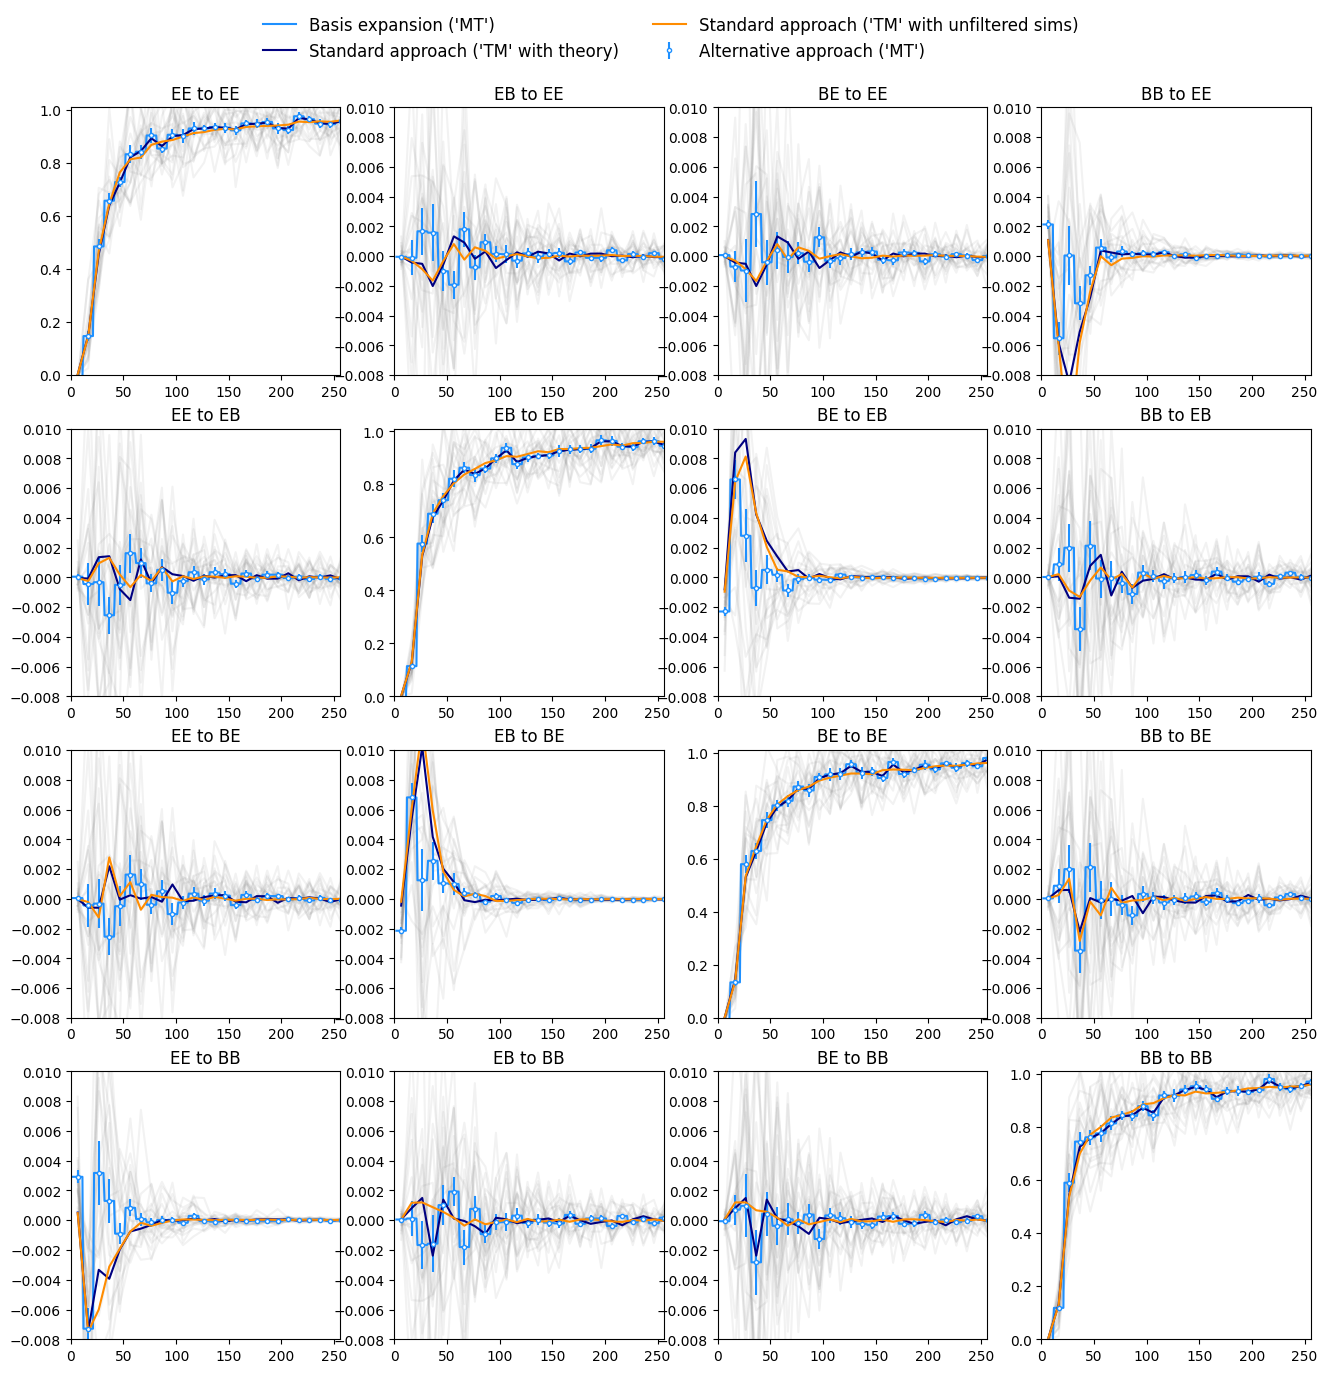

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, fp1 in enumerate(["EE", "EB", "BE", "BB"]):
    for j, fp2 in enumerate(["EE", "EB", "BE", "BB"]):
        for iii in range(n_sims):
            axes[i, j].plot(b.get_effective_ells(), T_persim[iii, i, :, j], color="gray", alpha=0.1)

        axes[i, j].errorbar(
            b.get_effective_ells(),
            T[i, :, j],
            yerr=T_std[i, :, j]/np.sqrt(n_sims),
            marker=".",
            ls="None",
            label="Alternative approach ('MT')",
            color="DodgerBlue",
            markerfacecolor="white"
        )
        axes[i, j].plot(
            ell[2:],
            phiT[i, :, j][2:],
            color="DodgerBlue",
            label="Basis expansion ('MT')"
        )
        axes[i, j].plot(
            b.get_effective_ells(),
            tf_old_th[i, j, :],
            color="navy",
            label="Standard approach ('TM' with theory)"
        )
        axes[i, j].plot(
            b.get_effective_ells(),
            tf_old[i, j, :],
            color="darkorange",
            label="Standard approach ('TM' with unfiltered sims)"
        )
        axes[i, j].set_title(f"{fp2} to {fp1}")
        axes[i, j].set_xlim(0, 2*nside)
        if i==j:
            axes[i, j].set_ylim(0., 1.01)
        else:
            axes[i, j].set_ylim(-0.008, 0.01)

# Write a legend for the figure
# remove duplicate in the legend (consider only one axis)
handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.9),
    ncol=2,
    fontsize=12,
    frameon=False
);

### A quick look at bandpower window functions, in the alternative approach case ("MT")

In [13]:
# For binned couplings and inverse couplings
mcm_phiT = np.einsum("AiCj,CjB->AiBj", mcm, phiT)
couplings = bin_mcm_left(mcm_phiT, b)
couplings = bin_mcm_right(couplings, b)
inv_couplings = np.linalg.inv(couplings.reshape([4*nb, 4*nb])).reshape([4, nb, 4, nb])

mcm_phiT_bin_left = bin_mcm_left(mcm_phiT, b)
bp_win = np.einsum("AkCp,CpBi->AkBi", inv_couplings, mcm_phiT_bin_left)

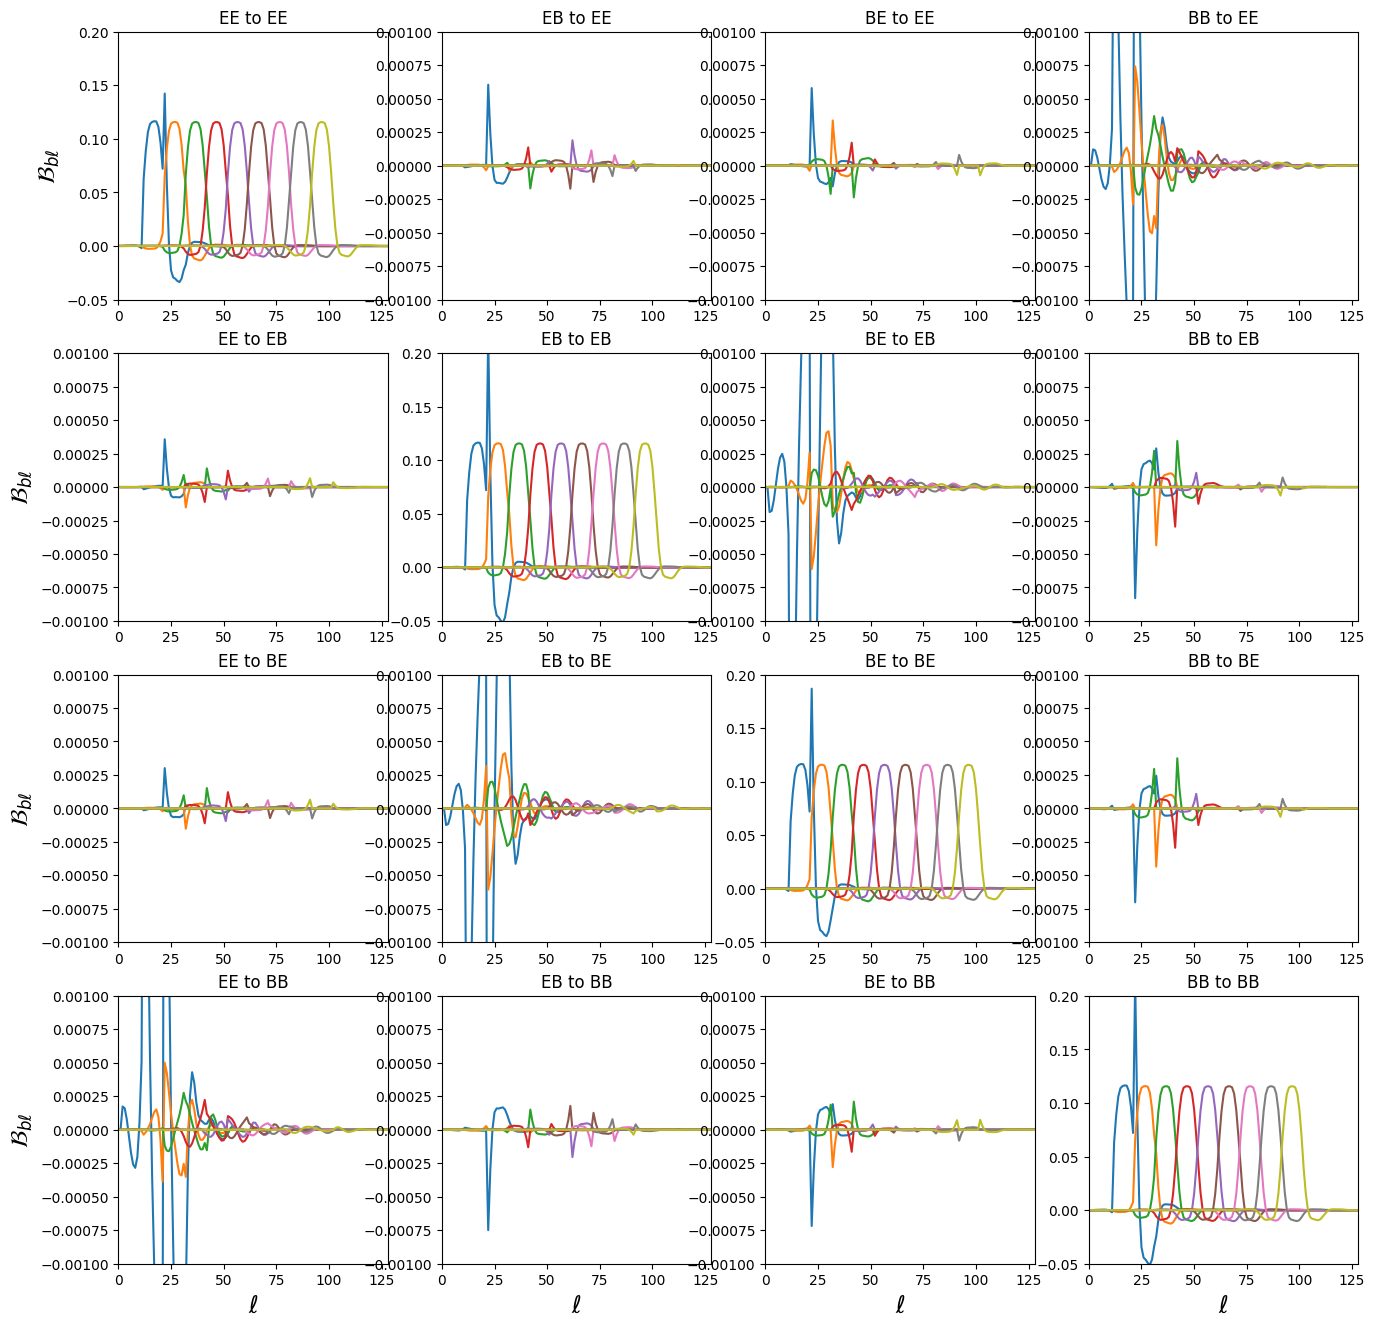

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        for idb in range(nb)[1:10]:
            axes[i, j].plot(ell, bp_win[i, idb, j, :])
        axes[i, j].set_title(f"{['EE', 'EB', 'BE', 'BB'][j]} to {['EE', 'EB', 'BE', 'BB'][i]}")
        axes[i, j].set_xlim(0, nside)
        if i == j:
            axes[i, j].set_ylim(-0.05, 0.2)
        else:
            axes[i, j].set_ylim(-1e-3, 1e-3)
        if j == 0:
            axes[i, j].set_ylabel(r"$\mathcal{B}_{b\ell}$", fontsize=17)
        if i == 3:
            axes[i, j].set_xlabel(r"$\ell$", fontsize=17)